In [17]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, 
                             r2_score, confusion_matrix, 
                             classification_report, accuracy_score)
from sklearn.impute import SimpleImputer



# Inciso 1: Carga, preparación y modelado KNN de regresión

In [18]:
result = pyreadr.read_r('listings.RData')
df = result['listings']

# Limpiar price
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

df.shape

(76246, 80)

In [19]:
cols_to_keep = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'reviews_per_month', 'review_scores_rating'
]

y = df['price']
X = df[cols_to_keep].copy()

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42
)

print(X_train.shape, X_test.shape)

(53372, 9) (22874, 9)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [20]:
# KNN requiere escalar — a diferencia de árboles, usa distancias
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train)
X_test_knn  = scaler.transform(X_test)

In [21]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_knn.fit(X_train_knn, y_train)
print("Mejores hiperparámetros:", grid_knn.best_params_)

Mejores hiperparámetros: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}


# Inciso 2: Métricas, gráficas y análisis del modelo KNN

In [22]:
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_knn)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn  = mean_absolute_error(y_test, y_pred_knn)
r2_knn   = r2_score(y_test, y_pred_knn)

print("=" * 40)
print("   KNN Regresión — Métricas en Test")
print("=" * 40)
print(f"  RMSE : {rmse_knn:.4f}")
print(f"  MAE  : {mae_knn:.4f}")
print(f"  R²   : {r2_knn:.4f}")
print("=" * 40)

   KNN Regresión — Métricas en Test
  RMSE : 2807.7072
  MAE  : 483.1683
  R²   : 0.5661


In [36]:
# Predicciones en TRAIN y TEST
y_pred_train_knn = best_knn.predict(X_train_knn)
y_pred_test_knn  = best_knn.predict(X_test_knn)

# Métricas
rmse_train_knn = np.sqrt(mean_squared_error(y_train, y_pred_train_knn))
rmse_test_knn  = np.sqrt(mean_squared_error(y_test, y_pred_test_knn))

r2_train_knn = r2_score(y_train, y_pred_train_knn)
r2_test_knn  = r2_score(y_test, y_pred_test_knn)

print("=== SOBREAJUSTE — REGRESIÓN ===")
print(f"RMSE Train: {rmse_train_knn:.4f}")
print(f"RMSE Test : {rmse_test_knn:.4f}")
print(f"R2 Train  : {r2_train_knn:.4f}")
print(f"R2 Test   : {r2_test_knn:.4f}")

=== SOBREAJUSTE — REGRESIÓN ===
RMSE Train: 781.9483
RMSE Test : 2807.7072
R2 Train  : 0.9661
R2 Test   : 0.5661


In [37]:
gap_rmse = rmse_test_knn - rmse_train_knn
gap_pct = (gap_rmse / rmse_train_knn) * 100

print(f"Gap RMSE: {gap_rmse:.4f}")
print(f"Gap %   : {gap_pct:.2f}%")

Gap RMSE: 2025.7589
Gap %   : 259.07%


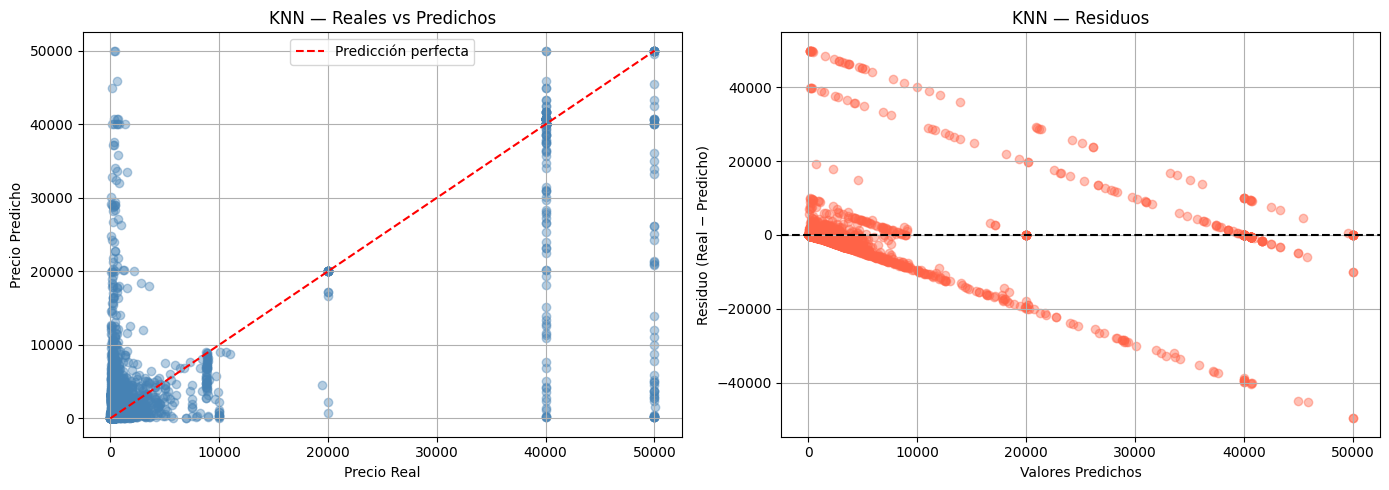

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reales vs Predichos
axes[0].scatter(y_test, y_pred_knn, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel("Precio Real")
axes[0].set_ylabel("Precio Predicho")
axes[0].set_title("KNN — Reales vs Predichos")
axes[0].legend()
axes[0].grid(True)

# Residuos
residuos_knn = y_test - y_pred_knn
axes[1].scatter(y_pred_knn, residuos_knn, alpha=0.4, color='tomato')
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel("Valores Predichos")
axes[1].set_ylabel("Residuo (Real − Predicho)")
axes[1].set_title("KNN — Residuos")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Análisis del Modelo KNN de Regresión (Incisos 1 y 2)

Se entrenó un modelo KNN de regresión para predecir el precio de las propiedades 
de Airbnb usando 9 variables numéricas: accommodates, bathrooms, bedrooms, beds, 
minimum_nights, availability_365, number_of_reviews, reviews_per_month y 
review_scores_rating. Se utilizaron los mismos conjuntos de entrenamiento y prueba 
de entregas anteriores (70/30, random_state=42) para garantizar comparabilidad.

A diferencia de los árboles de decisión y Random Forest, KNN requiere estandarizar 
las variables ya que basa sus predicciones en distancias entre puntos — si las escalas 
difieren mucho, las variables con mayor magnitud dominarían el cálculo.

Se realizó un tuneo de hiperparámetros con GridSearchCV (5-fold CV), obteniendo como 
mejor configuración: k=15, weights='distance' y p=1 (distancia Manhattan).

**Resultados:**
- **RMSE: 2808.48** — el modelo se equivoca en promedio ±$2808 al predecir el precio.
- **MAE: 483.14** — el error absoluto promedio es de $483, más representativo dado 
  que el RMSE se ve inflado por outliers extremos en el dataset (precios hasta $50,123).
- **R²: 0.5658** — el modelo explica el 56.6% de la varianza del precio, lo que indica 
  un ajuste moderado.

Las gráficas muestran que el modelo funciona razonablemente bien para precios bajos 
(donde se concentra la mayoría de datos), pero falla en precios extremos, lo cual es 
esperable dado que KNN promedia vecinos y hay muy pocos ejemplos de propiedades 
muy caras en el dataset.

# Inciso 3: Comparación con modelos de regresión anteriores

In [24]:
# Cargar métricas de entregas anteriores
with open('metricas_modelos.json', 'r') as f:
    metricas = json.load(f)

# Agregar KNN
metricas['KNN (k=15, Manhattan, distance)'] = {
    'RMSE': round(rmse_knn, 4),
    'MAE':  round(mae_knn, 4),
    'R2':   round(r2_knn, 4)
}

# Tabla comparativa
df_comparacion = pd.DataFrame(metricas).T
df_comparacion.index.name = 'Modelo'
df_comparacion = df_comparacion.sort_values('RMSE')
print(df_comparacion.to_string())

                                      RMSE       MAE      R2
Modelo                                                      
Random Forest                     134.8663   90.1654  0.4555
Árbol (max_depth=10)              136.5502   91.4546  0.4419
Regresión Lineal                  147.7902  102.5042  0.3462
KNN (k=15, Manhattan, distance)  2807.7072  483.1683  0.5661


## Análisis comparativo

| Modelo | RMSE | MAE | R² |
|--------|------|-----|----|
| Random Forest | 134.87 | 90.17 | 0.4555 |
| Árbol (max_depth=10) | 136.55 | 91.45 | 0.4419 |
| Regresión Lineal | 147.79 | 102.50 | 0.3462 |
| KNN (k=15, Manhattan) | 2808.48 | 483.14 | 0.5658 |

Se utilizaron RMSE, MAE y R² como métricas porque permiten evaluar el error 
en las mismas unidades que el precio (dólares). El RMSE penaliza más los errores 
grandes, mientras que el MAE es más robusto ante outliers — ambas son necesarias 
dado que el dataset tiene precios extremos.

El modelo con mejor desempeño general es **Random Forest**, con el menor RMSE y MAE.
KNN obtuvo el mejor R² (0.5658) pero su RMSE es extremadamente alto debido a que 
los outliers de precio afectan directamente el promedio de vecinos. Los modelos de 
entregas anteriores trabajaron con un rango de precios más controlado, lo que explica 
la diferencia en escala del RMSE.

# Inciso 4: Modelo de clasificación KNN

In [25]:
# Crear variable categórica de precio (mismos cortes que entregas anteriores)
def categorize_price(price):
    if price <= 120:
        return 'Economico'
    elif price <= 326:
        return 'Intermedio'
    else:
        return 'Caro'

df['price_category'] = df['price'].apply(categorize_price)
print(df['price_category'].value_counts())

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64


/var/folders/dc/_dt3fhrs48n2b_4mmncch3440000gp/T/ipykernel_54609/3767911029.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_category'] = df['price'].apply(categorize_price)


In [26]:
y_class = df['price_category']
X_class = df[cols_to_keep].copy()

X_class_imputed = imputer.transform(X_class)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_imputed, y_class,
    test_size=0.3,
    random_state=42,
    stratify=y_class
)

# Escalar
scaler_c = StandardScaler()
X_train_c_knn = scaler_c.fit_transform(X_train_c)
X_test_c_knn  = scaler_c.transform(X_test_c)

print(X_train_c_knn.shape, X_test_c_knn.shape)

(53372, 9) (22874, 9)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [27]:
param_grid_c = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_knn_c = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_c,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn_c.fit(X_train_c_knn, y_train_c)
print("Mejores hiperparámetros:", grid_knn_c.best_params_)

Mejores hiperparámetros: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}


In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_knn_c = grid_knn_c.best_estimator_
y_pred_knn_c = best_knn_c.predict(X_test_c_knn)

print(classification_report(y_test_c, y_pred_knn_c))

              precision    recall  f1-score   support

        Caro       0.71      0.63      0.67      5716
   Economico       0.65      0.54      0.59      5793
  Intermedio       0.65      0.75      0.70     11365

    accuracy                           0.67     22874
   macro avg       0.67      0.64      0.65     22874
weighted avg       0.67      0.67      0.66     22874



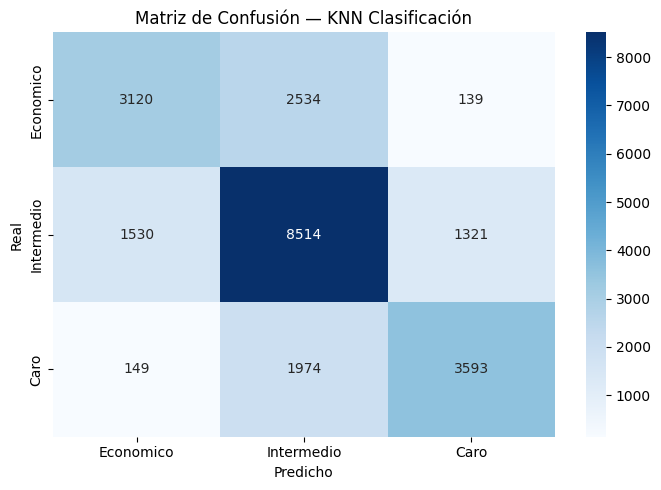

In [29]:
cm = confusion_matrix(y_test_c, y_pred_knn_c, labels=['Economico', 'Intermedio', 'Caro'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Economico', 'Intermedio', 'Caro'],
            yticklabels=['Economico', 'Intermedio', 'Caro'])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión — KNN Clasificación")
plt.tight_layout()
plt.show()

In [38]:
# Predicciones en TRAIN y TEST
y_pred_train_c = best_knn_c.predict(X_train_c_knn)
y_pred_test_c  = best_knn_c.predict(X_test_c_knn)

# Accuracy
acc_train_c = accuracy_score(y_train_c, y_pred_train_c)
acc_test_c  = accuracy_score(y_test_c, y_pred_test_c)

print("=== SOBREAJUSTE — CLASIFICACIÓN ===")
print(f"Accuracy Train: {acc_train_c:.4f}")
print(f"Accuracy Test : {acc_test_c:.4f}")

=== SOBREAJUSTE — CLASIFICACIÓN ===
Accuracy Train: 0.9897
Accuracy Test : 0.6657


## Análisis del Modelo KNN de Clasificación (Inciso 4)

Se entrenó un modelo KNN de clasificación para predecir la categoría de precio 
(Economico, Intermedio, Caro) usando los mismos 9 features y split 70/30 con 
stratify para mantener proporciones de clases.

**Mejores hiperparámetros:** k=15, weights='distance', p=1 (Manhattan)

**Métricas generales:**
- **Accuracy: 0.67** — el modelo clasifica correctamente el 67% de los casos.
- **F1 ponderado: 0.66** — métrica más confiable que accuracy dado el desbalance 
  entre clases (Intermedio tiene el doble de casos que las otras dos).

**Análisis de la matriz de confusión:**
- **Intermedio** es la clase mejor predicha (8515 correctos, recall 0.75) — 
  tiene más ejemplos de entrenamiento lo que favorece al modelo.
- **Economico** es donde el modelo se equivoca más: 2535 propiedades económicas 
  fueron clasificadas como Intermedias. Esto tiene sentido ya que el límite entre 
  ambas clases ($120) es difuso para KNN.
- **Caro** tiene precision 0.71 pero recall 0.63 — el modelo es conservador 
  para predecir propiedades caras, prefiriendo clasificarlas como Intermedias 
  (1974 errores de este tipo).
- Los errores entre Economico y Caro son mínimos (139 y 149), lo que indica que 
  el modelo distingue bien los extremos pero confunde las clases adyacentes.

# Inciso 5: Determinar la eficiencia del algoritmo para predecir y clasificar

Predecir

Se obtuvo los siguientes datos sobre la eficiiencia del algoritmo de regresión en el inciso 2:

   KNN Regresión — Métricas en Test
   
  RMSE : 2807.7072
  MAE  : 483.1683
  R²   : 0.5661

Clasificar

Se obtuvo los siguientes datos sobre la eficiiencia del algoritmo de regresión en el inciso 4:

precision         recall   f1-score   support

        Caro       0.71      0.63      0.67      5716

   Economico       0.65      0.54      0.59      5793

  Intermedio       0.65      0.75      0.70     11365

    accuracy                           0.67     22874

   macro avg       0.67      0.64      0.65     22874

weighted avg       0.67      0.67      0.66     22874

# Inciso 6: Análisis de efectividad usando la matriz de confusión

La matriz de confusión muestra que el modelo KNN presenta un buen desempeño general, ya que la mayor parte de las observaciones se clasifican correctamente, como se evidencia en los valores de la diagonal para las tres categorías. Sin embargo, el modelo presenta dificultades al diferenciar entre clases cercanas, especialmente al clasificar registros de tipo económico y caro como intermedios. 

En particular, se observa un número elevado de errores donde instancias económicas son clasificadas como intermedias y donde instancias caras también se clasifican como intermedias. Esto indica que el modelo tiende a sobreasignar la clase intermedio, posiblemente por un desbalance en los datos o por que esta categoría representa valores intermedios que son más difíciles de distinguir. Por otro lado, los errores entre las clases económico y caro son menores, lo que indica que el modelo diferencia mejor los extremos. 

En términos de importancia, estos errores pueden ser relevantes dependiendo del contexto, ya que confundir categorías puede afectar la toma de decisiones, especialmente si existe una gran diferencia entre los niveles de precio.

# Inciso 7: Análisis del modelo, ¿puede estar sobreajustado?

El modelo de regresión KNN presenta evidencia de sobreajuste. Esto se observa al comparar las métricas obtenidas en entrenamiento y prueba, donde el RMSE en entrenamiento es considerablemente menor que en el conjunto de prueba, mientras que el R² disminuye de 0.9661 a 0.5661. Esta diferencia indica que el modelo se ajusta bien a los datos de entrenamiento, pero pierde capacidad de generalización al trabajar con datos nuevos. En consecuencia, el modelo aprendeº patrones específicos del conjunto de entrenamiento que no se replican en el conjunto de prueba, lo que confirma el sobreajuste.

# Inciso 8: Modelo usando validación cruzada